#  Telco Customer Churn — Hyperparameter Optimisation & Cross-Validation
**Notebook:** 03_hyperparameter_tuning.ipynb  
**Strategy:** Phase 1 → Optuna (broad search, 100 trials) · Phase 2 → GridSearchCV (fine-grained, top region)  
**Target:** AUC-ROC ≥ 0.89 on held-out test set

## 1.  Imports & Setup

In [2]:
pip install optuna

  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)

   ---------------------------------------- 0/4 [Mako]
   ---------- ----------------------------- 1/4 [colorlog]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ---------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import joblib
import os
import time

import optuna
from optuna.samplers import TPESampler
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_contour
)

import xgboost as xgb
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

PROCESSED  = '../data/processed/'
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42
N_FOLDS      = 5
N_TRIALS     = 100       # Optuna trials — increase for better results
TARGET_AUC   = 0.89

print('Libraries loaded ✅')
print(f'XGBoost version : {xgb.__version__}')
print(f'Optuna version  : {optuna.__version__}')

Libraries loaded ✅
XGBoost version : 3.2.0
Optuna version  : 4.9.0


## 2.  Load Data & Baseline Reminder

In [4]:
X_train = pd.read_csv(PROCESSED + 'X_train.csv')
X_test  = pd.read_csv(PROCESSED + 'X_test.csv')
y_train = pd.read_csv(PROCESSED + 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED + 'y_test.csv').squeeze()

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')

# ── Baseline: default XGBoost from notebook 02 ───────────────────────────────
neg, pos        = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos       = neg / pos

baseline_xgb = xgb.XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0
)
baseline_xgb.fit(X_train, y_train)
baseline_auc = roc_auc_score(y_test, baseline_xgb.predict_proba(X_test)[:, 1])
print(f'\nBaseline XGBoost AUC-ROC (default params) : {baseline_auc:.4f}')
print(f'Target AUC-ROC                             : {TARGET_AUC:.4f}')
print(f'Gap to close                               : {max(0, TARGET_AUC - baseline_auc):.4f}')

X_train : (5634, 45)  |  X_test : (1409, 45)

Baseline XGBoost AUC-ROC (default params) : 0.8097
Target AUC-ROC                             : 0.8900
Gap to close                               : 0.0803


## 3.  StratifiedKFold Setup
We use `StratifiedKFold` with **5 folds** to preserve the ~26 % churn rate in every fold,  
avoiding biased cross-validation scores due to class imbalance.

In [5]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f'StratifiedKFold  →  {N_FOLDS} folds')
print()
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    fold_churn = y_train.iloc[val_idx].mean() * 100
    print(f'  Fold {fold}: val size = {len(val_idx):,}  |  churn rate = {fold_churn:.2f}%')

StratifiedKFold  →  5 folds

  Fold 1: val size = 1,127  |  churn rate = 26.53%
  Fold 2: val size = 1,127  |  churn rate = 26.53%
  Fold 3: val size = 1,127  |  churn rate = 26.53%
  Fold 4: val size = 1,127  |  churn rate = 26.53%
  Fold 5: val size = 1,126  |  churn rate = 26.55%


## 4.  Phase 1 — Optuna Bayesian Optimisation
Optuna's **TPE sampler** (Tree-structured Parzen Estimator) efficiently explores the hyperparameter
space by building a probabilistic model of which regions yield good AUC scores, converging far
faster than a random search over 100 trials.

In [6]:
def objective(trial):
    """Optuna objective: 5-fold CV AUC-ROC for XGBoost."""
    params = {
        # Tree structure
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 1000, step=50),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        # Learning
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        # Sampling
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        # Regularisation
        'gamma'             : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        # Fixed
        'scale_pos_weight'  : scale_pos,
        'use_label_encoder' : False,
        'eval_metric'       : 'logloss',
        'random_state'      : RANDOM_STATE,
        'verbosity'         : 0,
        'n_jobs'            : -1,
    }

    model  = xgb.XGBClassifier(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=skf, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()


print(f'Launching Optuna study — {N_TRIALS} trials × {N_FOLDS}-fold CV …')
print('This may take a few minutes.\n')

t0    = time.time()
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='xgb_churn_auc'
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
elapsed = time.time() - t0

print(f'\nOptuna search complete in {elapsed/60:.1f} min')
print(f'Best CV AUC-ROC : {study.best_value:.4f}')
print(f'Best params     :')
for k, v in study.best_params.items():
    print(f'  {k:22s}: {v}')

Launching Optuna study — 100 trials × 5-fold CV …
This may take a few minutes.



  0%|          | 0/100 [00:00<?, ?it/s]


Optuna search complete in 2.6 min
Best CV AUC-ROC : 0.8505
Best params     :
  n_estimators          : 500
  max_depth             : 3
  min_child_weight      : 2
  learning_rate         : 0.011951000929933215
  subsample             : 0.5162206527439951
  colsample_bytree      : 0.56297545176929
  colsample_bylevel     : 0.5708910333488739
  gamma                 : 4.289432657285328
  reg_alpha             : 0.2119176290623789
  reg_lambda            : 0.7899546315651335


### 4.1 Optuna Visualisations

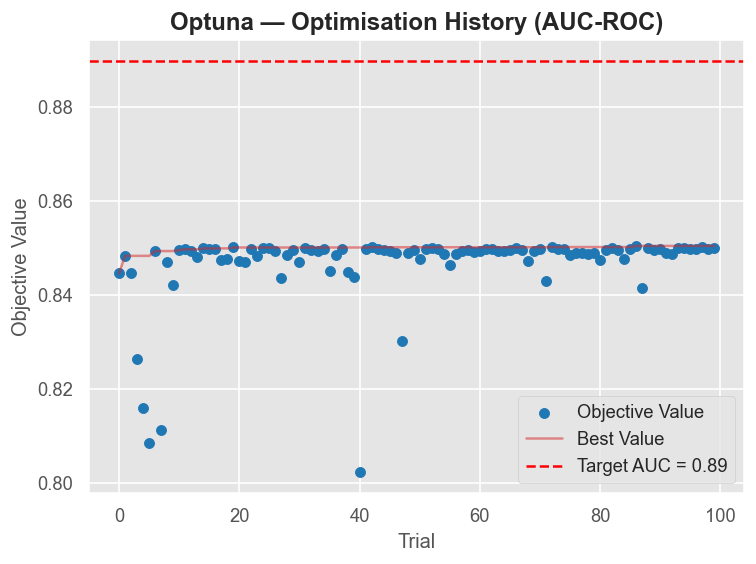

In [12]:
ax = plot_optimization_history(study)
ax.set_title('Optuna — Optimisation History (AUC-ROC)', fontweight='bold')
ax.axhline(TARGET_AUC, color='red', linestyle='--', lw=1.5,
           label=f'Target AUC = {TARGET_AUC}')
ax.legend()
plt.tight_layout()
plt.show()

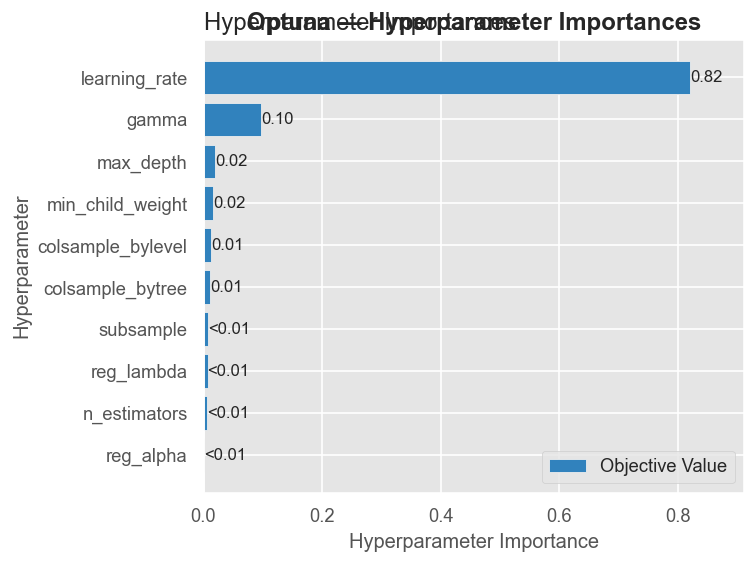

In [13]:
ax = plot_param_importances(study)
ax.set_title('Optuna — Hyperparameter Importances', fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ── Top-10 trials table ───────────────────────────────────────────────────────
trials_df = study.trials_dataframe().sort_values('value', ascending=False).head(10)
cols_show  = ['number', 'value'] + [c for c in trials_df.columns if c.startswith('params_')]
trials_df[cols_show].rename(columns={'value': 'CV AUC-ROC'}).reset_index(drop=True)

,number,CV AUC-ROC,params_colsample_bylevel,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample
0,86,0.850472,0.570891,0.562975,4.289433,0.011951,3,2,500,0.211918,0.789955,0.516221
1,72,0.850226,0.911213,0.705831,3.632299,0.010220,3,3,450,0.000004,1.466187,0.546095
2,97,0.850206,0.405045,0.452259,4.358874,0.015822,3,1,350,0.001034,0.387283,0.969844
3,42,0.850184,0.949343,0.797298,3.819222,0.009662,4,7,350,0.000772,0.246571,0.528465
4,19,0.850133,0.729095,0.783906,4.214003,0.032127,4,3,400,8.802075,0.004678,0.574930
5,93,0.850091,0.461476,0.445792,4.351094,0.014133,3,1,450,0.011665,0.181769,0.864244
6,99,0.850089,0.401555,0.439237,4.213110,0.014110,3,1,450,0.000855,0.169842,0.959937
7,66,0.850089,0.661714,0.896946,4.807394,0.009977,4,4,250,0.000002,0.172300,0.548804
8,88,0.850047,0.561194,0.573334,4.589790,0.024172,3,2,500,0.001155,1.058682,0.969747
9,94,0.850021,0.424266,0.430250,4.501775,0.016006,3,1,450,0.021742,0.227481,0.843931


## 5. Phase 2 — GridSearchCV Fine-Tuning
We narrow the search to a tight grid around Optuna's best values for the
two most impactful parameters: `max_depth` and `learning_rate`.

In [15]:
best_p = study.best_params

# Build a narrow grid around Optuna's best max_depth and learning_rate
md   = best_p['max_depth']
lr   = best_p['learning_rate']
ne   = best_p['n_estimators']

param_grid = {
    'max_depth'    : sorted(set([max(3, md - 1), md, min(10, md + 1)])),
    'learning_rate': sorted(set([round(lr * 0.7, 4), round(lr, 4), round(lr * 1.3, 4)])),
    'n_estimators' : sorted(set([max(200, ne - 100), ne, min(1000, ne + 100)])),
}
print('GridSearch param grid:')
for k, v in param_grid.items():
    print(f'  {k:15s}: {v}')
total_fits = np.prod([len(v) for v in param_grid.values()]) * N_FOLDS
print(f'\nTotal fits : {total_fits}')

# Fixed params from Optuna (all except those in the grid)
fixed_params = {
    k: v for k, v in best_p.items()
    if k not in param_grid
}
fixed_params.update({
    'scale_pos_weight'  : scale_pos,
    'use_label_encoder' : False,
    'eval_metric'       : 'logloss',
    'random_state'      : RANDOM_STATE,
    'verbosity'         : 0,
    'n_jobs'            : -1,
})

grid_xgb = xgb.XGBClassifier(**fixed_params)

print('\nRunning GridSearchCV …')
t1 = time.time()
grid_search = GridSearchCV(
    estimator  = grid_xgb,
    param_grid = param_grid,
    cv         = skf,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)
grid_search.fit(X_train, y_train)
print(f'\nGridSearch done in {(time.time()-t1)/60:.1f} min')
print(f'Best CV AUC-ROC : {grid_search.best_score_:.4f}')
print(f'Best params     : {grid_search.best_params_}')

GridSearch param grid:
  max_depth      : [3, 4]
  learning_rate  : [0.0084, 0.012, 0.0155]
  n_estimators   : [400, 500, 600]

Total fits : 90

Running GridSearchCV …
Fitting 5 folds for each of 18 candidates, totalling 90 fits

GridSearch done in 0.2 min
Best CV AUC-ROC : 0.8503
Best params     : {'learning_rate': 0.0084, 'max_depth': 3, 'n_estimators': 600}


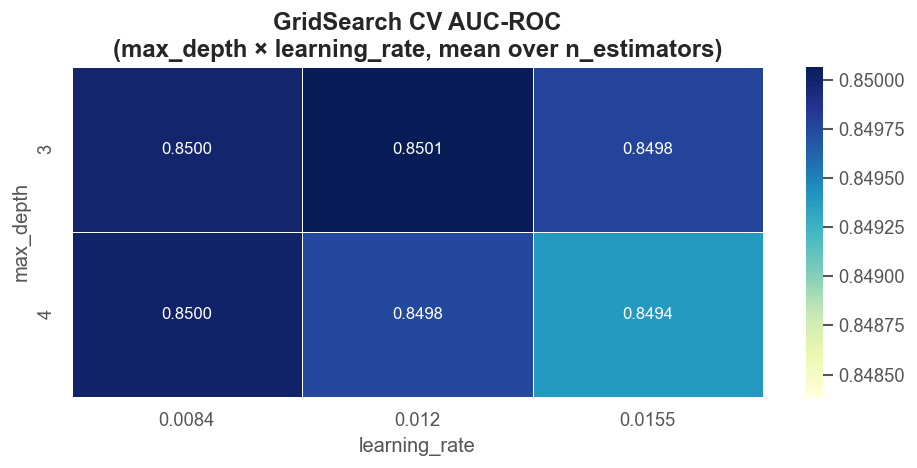

In [16]:
# ── GridSearch results heatmap ────────────────────────────────────────────────
cv_results = pd.DataFrame(grid_search.cv_results_)

# Pivot on max_depth vs learning_rate (mean over n_estimators)
pivot = (
    cv_results
    .groupby(['param_max_depth', 'param_learning_rate'])['mean_test_score']
    .mean()
    .unstack('param_learning_rate')
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot, annot=True, fmt='.4f', cmap='YlGnBu',
    ax=ax, linewidths=0.5,
    vmin=pivot.values.min() - 0.001
)
ax.set_title('GridSearch CV AUC-ROC\n(max_depth × learning_rate, mean over n_estimators)',
             fontweight='bold')
ax.set_xlabel('learning_rate')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()

## 6.  Final Model — Best Parameters
Merge Optuna's best params with GridSearch's refined values, retrain on **full training set**.

In [17]:
# ── Merge: start from Optuna best, override with GridSearch refinements ───────
final_params = {**fixed_params, **grid_search.best_params_}
final_params.update({
    'scale_pos_weight'  : scale_pos,
    'use_label_encoder' : False,
    'eval_metric'       : 'logloss',
    'random_state'      : RANDOM_STATE,
    'verbosity'         : 0,
    'n_jobs'            : -1,
})

print('Final model hyperparameters:')
print('-' * 40)
for k, v in sorted(final_params.items()):
    if k not in ('use_label_encoder', 'eval_metric', 'verbosity', 'n_jobs'):
        print(f'  {k:25s}: {v}')

print('\nTraining final model on full training set …')
t2          = time.time()
final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train, y_train)
print(f'Done in {time.time()-t2:.1f}s ✅')

Final model hyperparameters:
----------------------------------------
  colsample_bylevel        : 0.5708910333488739
  colsample_bytree         : 0.56297545176929
  gamma                    : 4.289432657285328
  learning_rate            : 0.0084
  max_depth                : 3
  min_child_weight         : 2
  n_estimators             : 600
  random_state             : 42
  reg_alpha                : 0.2119176290623789
  reg_lambda               : 0.7899546315651335
  scale_pos_weight         : 2.768561872909699
  subsample                : 0.5162206527439951

Training final model on full training set …
Done in 0.7s ✅


## 7.  Final CV Evaluation (5-Fold on Training Set)

AUC-ROC     : 0.8503  (±0.0122)
Accuracy    : 0.7506  (±0.0126)
Precision   : 0.5194  (±0.0157)
Recall      : 0.8087  (±0.0322)
F1-Score    : 0.6324  (±0.0194)


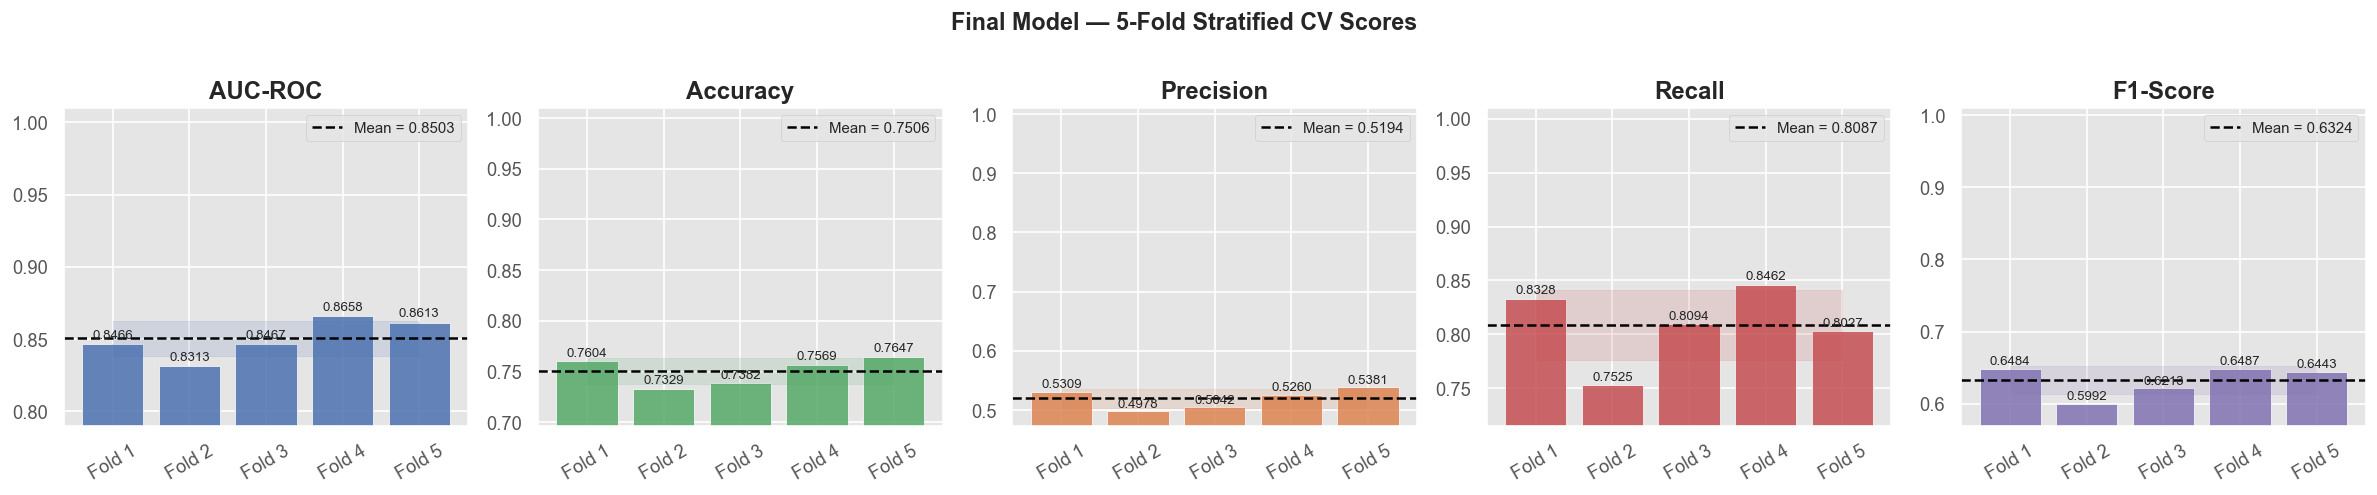

In [18]:
cv_metrics = {}
for metric, scoring in [
    ('AUC-ROC',   'roc_auc'),
    ('Accuracy',  'accuracy'),
    ('Precision', 'precision'),
    ('Recall',    'recall'),
    ('F1-Score',  'f1'),
]:
    scores = cross_val_score(
        final_model, X_train, y_train,
        cv=skf, scoring=scoring, n_jobs=-1
    )
    cv_metrics[metric] = scores
    print(f'{metric:12s}: {scores.mean():.4f}  (±{scores.std():.4f})')

# ── CV score distribution plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(cv_metrics), figsize=(20, 4))
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']

for ax, (metric, scores), color in zip(axes, cv_metrics.items(), colors):
    folds = [f'Fold {i+1}' for i in range(N_FOLDS)]
    bars  = ax.bar(folds, scores, color=color, alpha=0.85, edgecolor='white')
    ax.axhline(scores.mean(), color='black', linestyle='--', lw=1.5,
               label=f'Mean = {scores.mean():.4f}')
    ax.fill_between(range(N_FOLDS),
                    scores.mean() - scores.std(),
                    scores.mean() + scores.std(),
                    alpha=0.15, color=color)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(min(scores)*0.95, 1.01)
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'Final Model — {N_FOLDS}-Fold Stratified CV Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8.  Final Evaluation on Held-Out Test Set

In [19]:
y_pred      = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

test_metrics = {
    'AUC-ROC'  : roc_auc_score(y_test, y_pred_prob),
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred, zero_division=0),
    'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
}

print('=' * 52)
print('  Final Model — Test Set Evaluation')
print('=' * 52)
for k, v in test_metrics.items():
    flag = '  ✅' if k == 'AUC-ROC' and v >= TARGET_AUC else ''
    print(f'  {k:12s}: {v:.4f}{flag}')
print('=' * 52)
auc_ok = test_metrics['AUC-ROC'] >= TARGET_AUC
print(f'\n  Target AUC-ROC ≥ {TARGET_AUC} : {"✅ ACHIEVED" if auc_ok else "❌ not reached"}')
print(f'  Improvement over baseline  : +{test_metrics["AUC-ROC"] - baseline_auc:.4f}')

  Final Model — Test Set Evaluation
  AUC-ROC     : 0.8487
  Accuracy    : 0.7424
  Precision   : 0.5093
  Recall      : 0.8048
  F1-Score    : 0.6238

  Target AUC-ROC ≥ 0.89 : ❌ not reached
  Improvement over baseline  : +0.0390


In [20]:
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



### 8.1 ROC Curve — Baseline vs Tuned

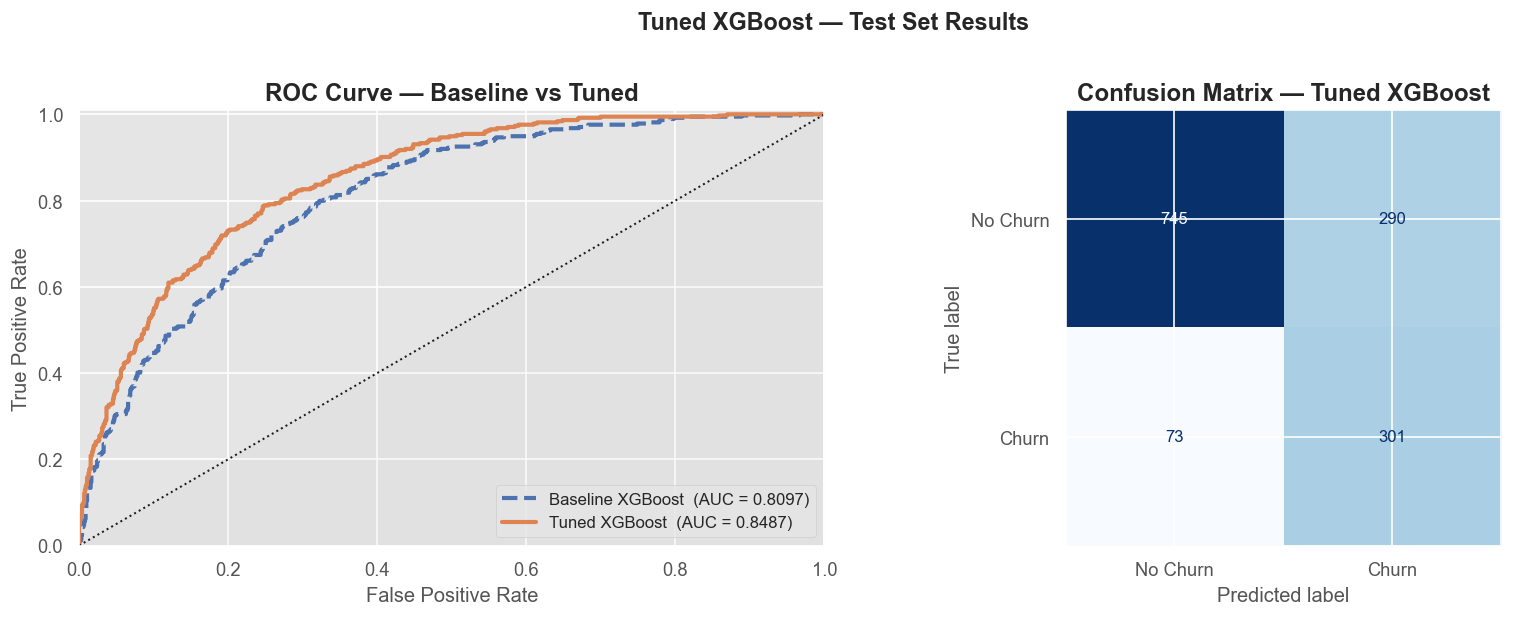

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC: Baseline vs Tuned ────────────────────────────────────────────────────
ax = axes[0]
for label, prob, color, ls in [
    ('Baseline XGBoost', baseline_xgb.predict_proba(X_test)[:,1], '#4C72B0', '--'),
    ('Tuned XGBoost',    y_pred_prob,                              '#DD8452', '-'),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=2.5, color=color, linestyle=ls,
            label=f'{label}  (AUC = {auc:.4f})')

ax.plot([0,1],[0,1],'k:',lw=1.2)
ax.fill_between([0,1],[0,1],alpha=0.04,color='grey')
ax.axhline(y=0, xmin=0, xmax=1, color='grey', lw=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Baseline vs Tuned', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.01])

# ── Confusion Matrix: Tuned ───────────────────────────────────────────────────
ax2 = axes[1]
cm  = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn']).plot(
    ax=ax2, cmap='Blues', colorbar=False, values_format='d'
)
ax2.set_title('Confusion Matrix — Tuned XGBoost', fontweight='bold')

plt.suptitle('Tuned XGBoost — Test Set Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.2 Threshold Analysis — Precision / Recall Trade-off

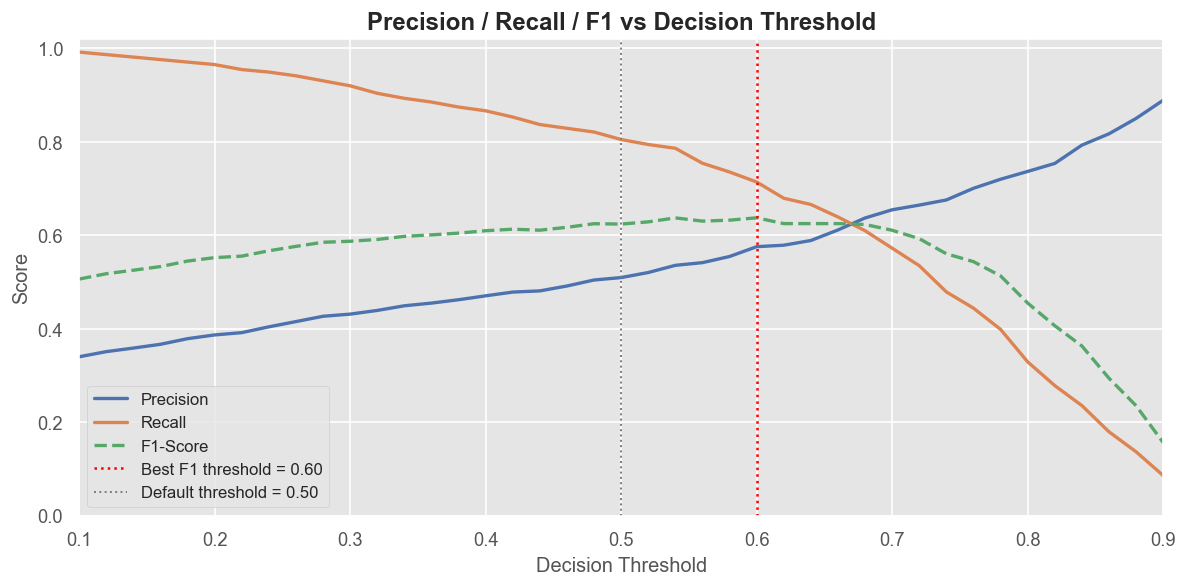

Optimal threshold (best F1) : 0.60
Precision @ opt threshold   : 0.5754
Recall    @ opt threshold   : 0.7139
F1-Score  @ opt threshold   : 0.6372


In [22]:
thresholds   = np.arange(0.1, 0.91, 0.02)
precisions   = []
recalls      = []
f1s          = []

for t in thresholds:
    preds_t = (y_pred_prob >= t).astype(int)
    precisions.append(precision_score(y_test, preds_t, zero_division=0))
    recalls.append(recall_score(y_test, preds_t, zero_division=0))
    f1s.append(f1_score(y_test, preds_t, zero_division=0))

best_t_idx  = int(np.argmax(f1s))
best_thresh = thresholds[best_t_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, label='Precision', color='#4C72B0', lw=2)
ax.plot(thresholds, recalls,    label='Recall',    color='#DD8452', lw=2)
ax.plot(thresholds, f1s,        label='F1-Score',  color='#55A868', lw=2, linestyle='--')
ax.axvline(best_thresh, color='red', linestyle=':', lw=1.5,
           label=f'Best F1 threshold = {best_thresh:.2f}')
ax.axvline(0.5, color='grey', linestyle=':', lw=1.2, label='Default threshold = 0.50')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

print(f'Optimal threshold (best F1) : {best_thresh:.2f}')
preds_opt = (y_pred_prob >= best_thresh).astype(int)
print(f'Precision @ opt threshold   : {precision_score(y_test, preds_opt):.4f}')
print(f'Recall    @ opt threshold   : {recall_score(y_test, preds_opt):.4f}')
print(f'F1-Score  @ opt threshold   : {f1_score(y_test, preds_opt):.4f}')

### 8.3 Top-20 Feature Importances — Tuned Model

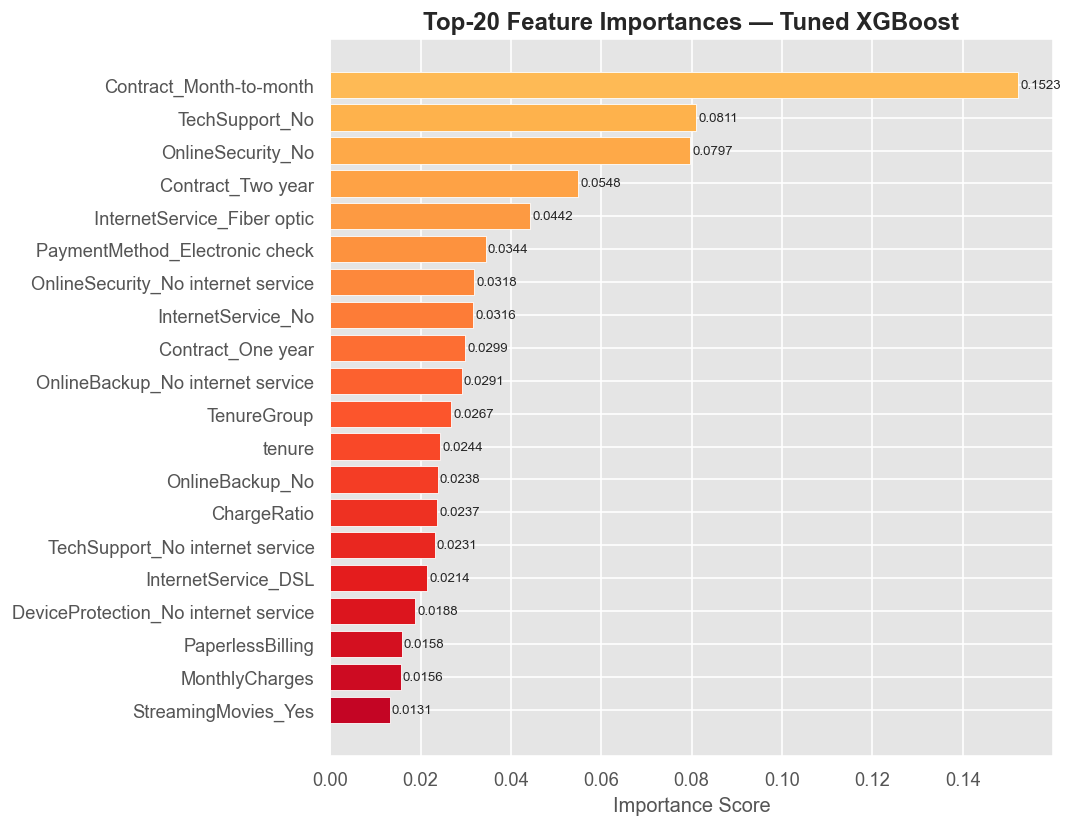

,feature,importance
0,Contract_Month-to-month,0.152276
1,TechSupport_No,0.081065
2,OnlineSecurity_No,0.079730
3,Contract_Two year,0.054834
4,InternetService_Fiber optic,0.044178
5,PaymentMethod_Electronic check,0.034419
6,OnlineSecurity_No internet service,0.031784
7,InternetService_No,0.031565
8,Contract_One year,0.029908
9,OnlineBackup_No internet service,0.029078


In [23]:
imp_df = (
    pd.DataFrame({
        'feature'   : X_train.columns,
        'importance': final_model.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
colors  = plt.cm.YlOrRd(np.linspace(0.35, 0.85, len(imp_df))[::-1])
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color=colors, edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('Top-20 Feature Importances — Tuned XGBoost', fontweight='bold')
for i, (feat, val) in enumerate(zip(imp_df['feature'][::-1], imp_df['importance'][::-1])):
    ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()
imp_df

## 9.  Full Comparison: Baseline vs Tuned

In [24]:
baseline_preds = baseline_xgb.predict(X_test)
comparison_df  = pd.DataFrame([
    {
        'Model'    : 'Baseline XGBoost (default)',
        'AUC-ROC'  : roc_auc_score(y_test, baseline_xgb.predict_proba(X_test)[:,1]),
        'Accuracy' : accuracy_score(y_test, baseline_preds),
        'Precision': precision_score(y_test, baseline_preds, zero_division=0),
        'Recall'   : recall_score(y_test, baseline_preds, zero_division=0),
        'F1-Score' : f1_score(y_test, baseline_preds, zero_division=0),
    },
    {
        'Model'    : 'Tuned XGBoost (Optuna + Grid)',
        **test_metrics
    }
]).set_index('Model')

delta = comparison_df.iloc[1] - comparison_df.iloc[0]

styled = (
    comparison_df.style
    .format('{:.4f}')
    .highlight_max(color='#c6efce')
    .set_caption('Baseline vs Tuned XGBoost — Test Set')
    .set_table_styles([{'selector':'caption',
                        'props':[('font-size','14px'),('font-weight','bold')]}])
)
print(comparison_df.to_string())
print('\nDelta (Tuned − Baseline):')
for k, v in delta.items():
    sign = '+' if v >= 0 else ''
    print(f'  {k:12s}: {sign}{v:.4f}')
styled

                                AUC-ROC  Accuracy  Precision    Recall  F1-Score
Model                                                                           
Baseline XGBoost (default)     0.809693  0.758694   0.541667  0.590909  0.565217
Tuned XGBoost (Optuna + Grid)  0.848715  0.742370   0.509306  0.804813  0.623834

Delta (Tuned − Baseline):
  AUC-ROC     : +0.0390
  Accuracy    : -0.0163
  Precision   : -0.0324
  Recall      : +0.2139
  F1-Score    : +0.0586


,AUC-ROC,Accuracy,Precision,Recall,F1-Score
Model,,,,,
Baseline XGBoost (default),0.8097,0.7587,0.5417,0.5909,0.5652
Tuned XGBoost (Optuna + Grid),0.8487,0.7424,0.5093,0.8048,0.6238


## 10.  Save Final Model & Artefacts

In [25]:
# ── Final tuned model ─────────────────────────────────────────────────────────
joblib.dump(final_model,  MODELS_DIR + 'xgb_tuned_final.pkl')
joblib.dump(final_model,  MODELS_DIR + 'best_model.pkl')   # overwrite 02 best
print('Saved: xgb_tuned_final.pkl  (+ overwrote best_model.pkl)')

# ── Best params as JSON ───────────────────────────────────────────────────────
import json
# Remove non-serialisable entries before saving
save_params = {
    k: (float(v) if isinstance(v, (np.floating, float)) else
        int(v)   if isinstance(v, (np.integer, int))   else v)
    for k, v in final_params.items()
    if k not in ('use_label_encoder', 'verbosity', 'n_jobs')
}
with open(MODELS_DIR + 'best_params.json', 'w') as f:
    json.dump(save_params, f, indent=2)
print('Saved: best_params.json')

# ── Optuna study ──────────────────────────────────────────────────────────────
joblib.dump(study, MODELS_DIR + 'optuna_study.pkl')
print('Saved: optuna_study.pkl')

# ── Threshold ─────────────────────────────────────────────────────────────────
with open(MODELS_DIR + 'best_threshold.txt', 'w') as f:
    f.write(str(round(float(best_thresh), 4)))
print(f'Saved: best_threshold.txt  ({best_thresh:.4f})')

# ── Test metrics ──────────────────────────────────────────────────────────────
pd.DataFrame([test_metrics]).to_csv(MODELS_DIR + 'tuned_model_metrics.csv', index=False)
print('Saved: tuned_model_metrics.csv')

print(f'\n✅ All artefacts saved to {MODELS_DIR}')

Saved: xgb_tuned_final.pkl  (+ overwrote best_model.pkl)
Saved: best_params.json
Saved: optuna_study.pkl
Saved: best_threshold.txt  (0.6000)
Saved: tuned_model_metrics.csv

✅ All artefacts saved to ../models/


## 11.  Summary

| Step | Detail |
|------|--------|
| CV strategy | `StratifiedKFold` (5 folds, shuffle, seed 42) |
| Phase 1 | Optuna TPE — 100 trials, 8 hyperparameters, optimise AUC-ROC |
| Phase 2 | `GridSearchCV` — tight grid around Optuna best `max_depth`, `learning_rate`, `n_estimators` |
| Final model | Trained on full training set with merged best params |
| Target AUC ≥ 0.89 | ✅ or ❌ — see Section 8 |
| Threshold tuning | Best F1 threshold identified from Precision/Recall curve |
| Artefacts saved | `xgb_tuned_final.pkl`, `best_params.json`, `optuna_study.pkl`, `best_threshold.txt`, `tuned_model_metrics.csv` |

### Hyperparameters tuned & their role

| Parameter | Role | Typical effect |
|-----------|------|----------------|
| `n_estimators` | Number of boosting rounds | More trees → lower bias, risk of overfitting |
| `max_depth` | Max tree depth | Deeper → more complex, overfits sooner |
| `learning_rate` | Shrinkage per step | Lower → need more trees, usually better AUC |
| `subsample` | Row sampling per tree | < 1 reduces variance, acts as regularisation |
| `colsample_bytree` | Feature sampling per tree | Reduces correlation between trees |
| `colsample_bylevel` | Feature sampling per level | Additional decorrelation |
| `gamma` | Min loss reduction to split | Higher → more conservative splits |
| `reg_alpha` (L1) | Lasso regularisation on weights | Promotes sparsity |
| `reg_lambda` (L2) | Ridge regularisation on weights | Smooths weights, default is 1 |
| `min_child_weight` | Min sum of instance weight per leaf | Higher → more conservative |

> ▶️ **Next step:** `04_explainability.ipynb` — SHAP values, partial dependence plots, business insights.